In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

In [9]:
footprints = pd.read_csv('../data/raw/Food_Production.csv')
merged_data = pd.read_csv('../data/processed/integrated_food_emissions_by_country_year_product.csv')

In [10]:
merged_data.columns

Index(['Area Code', 'Area', 'Item Code', 'Item', 'Element Code', 'Element',
       'Unit', 'Year', 'Production', 'Food product', 'Total_emissions',
       'Production_kg', 'Emissions_kgCO2eq', 'Emissions_MtCO2eq', 'Region'],
      dtype='object')

### STEP 2: Data Preparation & Feature Engineering

In [12]:
def engineer_features(merged_data):
    """Create features for regression model"""

    # 1. Aggregate production by category
    category_mapping = {
        'Grains': ['Wheat & Rye (Bread)', 'Maize (Meal)', 'Barley (Beer)', 'Oatmeal', 'Rice'],
        'Roots & Tubers': ['Potatoes', 'Cassava', 'Root Vegetables'],
        'Sugars': ['Cane Sugar', 'Beet Sugar'],
        'Pulses': ['Other Pulses', 'Peas'],
        'Nuts & Seeds': ['Nuts', 'Groundnuts'],
        'Vegetables': ['Tomatoes', 'Onions & Leeks', 'Brassicas', 'Other Vegetables'],
        'Fruits': ['Citrus Fruit', 'Bananas', 'Apples', 'Berries & Grapes', 'Other Fruit'],
        'Oils': ['Soybean Oil', 'Palm Oil', 'Sunflower Oil', 'Rapeseed Oil', 'Olive Oil'],
        'Meat - High Impact': ['Beef (beef herd)', 'Beef (dairy herd)', 'Lamb & Mutton'],
        'Meat - Medium Impact': ['Pig Meat', 'Poultry Meat'],
        'Dairy & Eggs': ['Milk', 'Cheese', 'Eggs'],
        'Seafood': ['Fish (farmed)', 'Shrimps (farmed)'],
        'Other': ['Soymilk', 'Tofu', 'Coffee', 'Dark Chocolate', 'Wine']
    }

    # Create category columns
    for category, products in category_mapping.items():
        category_production = merged_data[merged_data['Food product'].isin(products)]
        merged_data[f'Prod_{category.replace(" ", "_").replace("-", "_")}'] = 0.0

        # Sum production for products in this category
        for product in products:
            mask = merged_data['Food product'] == product
            merged_data.loc[mask, f'Prod_{category.replace(" ", "_").replace("-", "_")}'] = merged_data.loc[mask, 'Production_kg']

    # 2. Calculate emission source breakdown (per product)
    source_cols = ['Land use change', 'Animal Feed', 'Farm', 'Processing', 'Transport', 'Packging', 'Retail']

    # Create emission source features at country level
    for source in source_cols:
        if source in footprints.columns:
            # Create factor for each product
            source_factor = footprints[['Food product', source]].dropna()
            merged_source = merged_data.merge(source_factor, on='Food product', how='left')
            merged_data[f'Emission_{source.replace(" ", "_")}'] = (
                merged_source['Production_kg'] * merged_source[source].fillna(0)
            )

    return merged_data, category_mapping

merged_data, category_mapping = engineer_features(merged_data)

print(f"\nUnique values:")
print(f"  Countries: {merged_data['Area'].nunique()}")
print(f"  Years: {merged_data['Year'].min()} - {merged_data['Year'].max()}")
print(f"  Food products: {merged_data['Food product'].nunique()}")


Unique values:
  Countries: 245
  Years: 1961 - 2023
  Food products: 40


### STEP 3: AGGREGATE TO COUNTRY-YEAR LEVEL

In [13]:
regression_dataset = merged_data.groupby(['Area', 'Year']).agg({
    # Target variable (what we want to predict)
    'Emissions_MtCO2eq': 'sum',  # Total emissions per country-year

    # Production features (kg) - sum across products
    'Prod_Grains': 'sum',
    'Prod_Roots_&_Tubers': 'sum',
    'Prod_Sugars': 'sum',
    'Prod_Pulses': 'sum',
    'Prod_Nuts_&_Seeds': 'sum',
    'Prod_Vegetables': 'sum',
    'Prod_Fruits': 'sum',
    'Prod_Oils': 'sum',
    'Prod_Meat___High_Impact': 'sum',
    'Prod_Meat___Medium_Impact': 'sum',
    'Prod_Dairy_&_Eggs': 'sum',
    'Prod_Seafood': 'sum',
    'Prod_Other': 'sum',

    # Emission source features (kg CO2eq) - sum across products
    'Emission_Land_use_change': 'sum',
    'Emission_Animal_Feed': 'sum',
    'Emission_Farm': 'sum',
    'Emission_Processing': 'sum',
    'Emission_Transport': 'sum',
    'Emission_Packging': 'sum',
    'Emission_Retail': 'sum',

    # Metadata
    'Region': 'first'  # Take first region (same for all rows of same country)
}).reset_index()

print(f"Regression dataset shape: {regression_dataset.shape}")
regression_dataset.head(3)

Regression dataset shape: (14048, 24)


,Area,Year,Emissions_MtCO2eq,Prod_Grains,Prod_Roots_&_Tubers,Prod_Sugars,Prod_Pulses,Prod_Nuts_&_Seeds,Prod_Vegetables,Prod_Fruits,...,Prod_Seafood,Prod_Other,Emission_Land_use_change,Emission_Animal_Feed,Emission_Farm,Emission_Processing,Emission_Transport,Emission_Packging,Emission_Retail,Region
0,Afghanistan,1961,33.840240,7.371000e+09,260000000.0,92400000.0,36000000.0,21000000.0,582600000.0,924400000.0,...,0.0,444000000.0,2.983424e+09,1.129036e+09,2.417109e+10,1.553159e+09,1.416019e+09,1.379764e+09,1.207744e+09,Asia
1,Afghanistan,1962,34.384284,7.372000e+09,230000000.0,114456000.0,37200000.0,25200000.0,612600000.0,920000000.0,...,0.0,462056000.0,3.248259e+09,1.152831e+09,2.436199e+10,1.574162e+09,1.439325e+09,1.397095e+09,1.210625e+09,Asia
2,Afghanistan,1963,33.374946,6.735000e+09,244000000.0,109225000.0,39200000.0,21400000.0,649200000.0,933400000.0,...,0.0,476625000.0,3.275874e+09,1.225838e+09,2.339812e+10,1.514635e+09,1.407970e+09,1.355079e+09,1.197427e+09,Asia


## SPATIAL DATA MAP

In [15]:
import geopandas as gpd
import zipfile

# List contents of zip file
zip_path = '../110m_cultural.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    print("Files in zip:")
    for file_info in zip_ref.infolist():
        print(f"  {file_info.filename}")

    # Look for .shp, .geojson, or .gpkg files
    shp_files = [f for f in zip_ref.namelist() if f.endswith('.shp')]
    geojson_files = [f for f in zip_ref.namelist() if f.endswith('.geojson')]

    if shp_files:
        print(f"\nFound shapefile: {shp_files[0]}")
        # Read the shapefile directly from zip
        world = gpd.read_file(f'zip://{zip_path}!{shp_files[0]}')
    elif geojson_files:
        print(f"\nFound GeoJSON: {geojson_files[0]}")
        world = gpd.read_file(f'zip://{zip_path}!{geojson_files[0]}')

print(f"World map shape: {world.shape}")

Files in zip:
  ne_110m_populated_places_simple.prj
  ne_110m_admin_0_countries.shx
  ne_110m_admin_0_countries_lakes.shx
  ne_110m_admin_0_pacific_groupings.prj
  ne_110m_admin_0_countries.shp
  ne_110m_admin_0_countries.cpg
  ne_110m_admin_0_countries_lakes.cpg
  ne_110m_admin_1_states_provinces_lines.README.html
  ne_110m_admin_0_countries_lakes.shp
  ne_110m_admin_0_map_units.prj
  ne_110m_admin_1_states_provinces.prj
  ne_110m_populated_places.shx
  ne_110m_admin_0_boundary_lines_land.dbf
  ne_110m_admin_0_countries.VERSION.txt
  ne_110m_admin_0_scale_rank.dbf
  ne_110m_populated_places.cpg
  ne_110m_populated_places_simple.README.html
  ne_110m_populated_places.shp
  ne_110m_admin_1_states_provinces_lakes.dbf
  ne_110m_admin_1_states_provinces_lines.dbf
  ne_110m_admin_1_states_provinces.sbn
  ne_110m_admin_0_tiny_countries.VERSION.txt
  ne_110m_admin_0_pacific_groupings.VERSION.txt
  ne_110m_admin_0_countries_lakes.VERSION.txt
  ne_110m_admin_0_map_units.README.html
  ne_110m_ad

C:\Users\CMG\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopandas\plotting.py:950: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  ax.figure.canvas.draw_idle()
C:\Users\CMG\AppData\Local\Temp\ipykernel_4912\2497942076.py:19: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig('../outputs/figures/spatial_emissions_map.png', dpi=150)
C:\Users\CMG\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


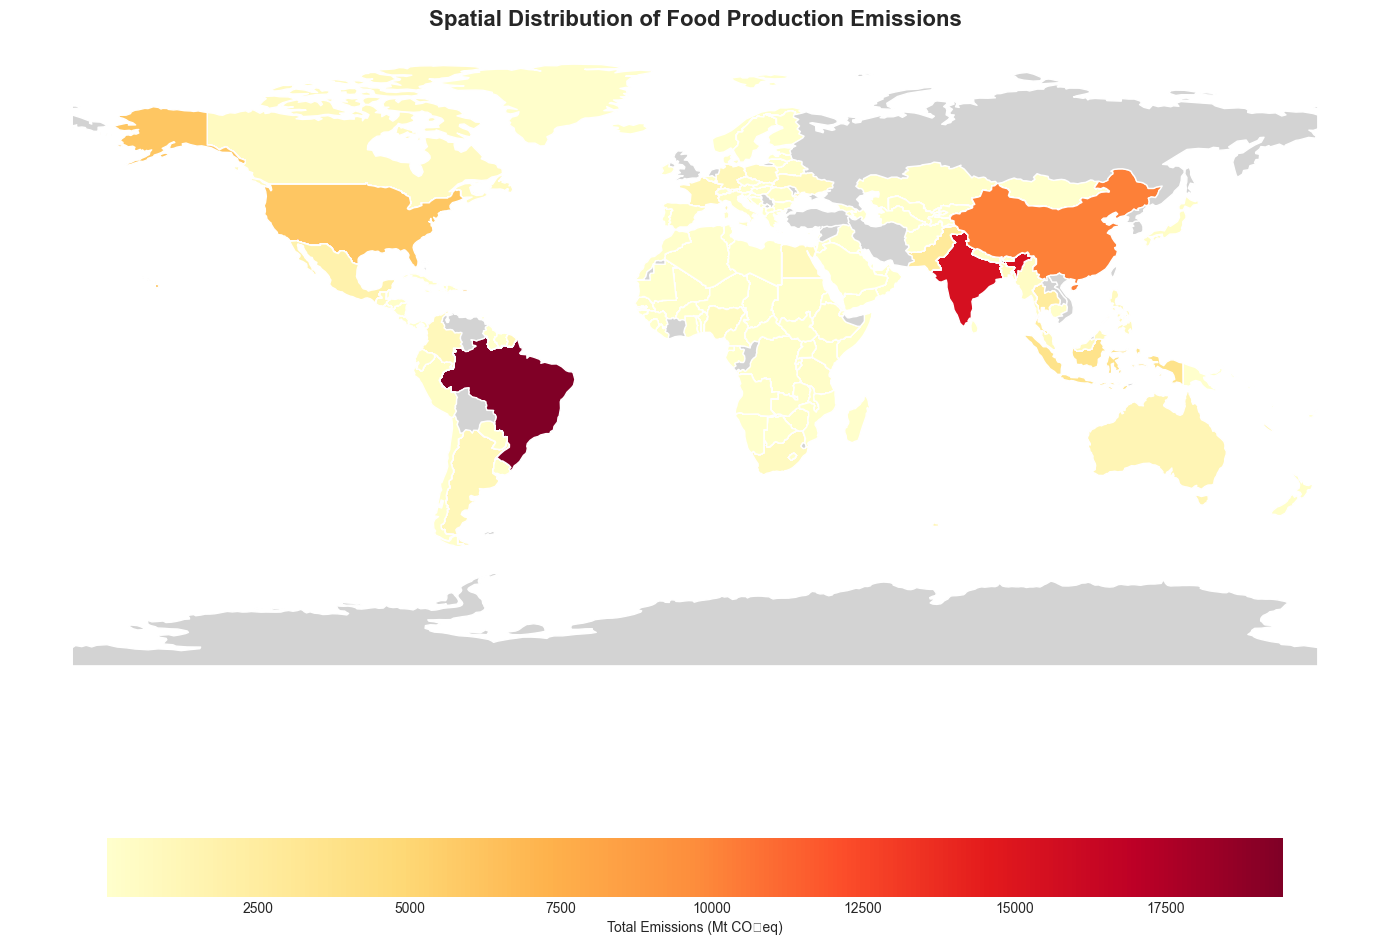

In [18]:

world_emissions = world.merge(
    regression_dataset[['Area', 'Emissions_MtCO2eq']].drop_duplicates(),
    left_on='SOVEREIGNT',
    right_on='Area',
    how='left'
)

# 4.2 Create spatial visualization
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_emissions.plot(column='Emissions_MtCO2eq', ax=ax, legend=True,
                     legend_kwds={'label': 'Total Emissions (Mt CO₂eq)',
                                  'orientation': 'horizontal',
                                  'shrink': 0.8},
                     cmap='YlOrRd', missing_kwds={'color': 'lightgray'})

ax.set_title('Spatial Distribution of Food Production Emissions', fontsize=16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../outputs/figures/spatial_emissions_map.png', dpi=150)
plt.show()

In [20]:
world_emissions

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,ADM0_A3,GEOU_DIF,GEOUNIT,GU_A3,SU_DIF,SUBUNIT,SU_A3,BRK_DIFF,NAME,NAME_LONG,BRK_A3,BRK_NAME,BRK_GROUP,ABBREV,POSTAL,FORMAL_EN,FORMAL_FR,NAME_CIAWF,NOTE_ADM0,NOTE_BRK,NAME_SORT,NAME_ALT,MAPCOLOR7,MAPCOLOR8,MAPCOLOR9,MAPCOLOR13,POP_EST,POP_RANK,POP_YEAR,GDP_MD,GDP_YEAR,ECONOMY,INCOME_GRP,FIPS_10,ISO_A2,ISO_A2_EH,ISO_A3,ISO_A3_EH,ISO_N3,ISO_N3_EH,UN_A3,WB_A2,WB_A3,WOE_ID,WOE_ID_EH,WOE_NOTE,ADM0_ISO,ADM0_DIFF,ADM0_TLC,ADM0_A3_US,ADM0_A3_FR,ADM0_A3_RU,ADM0_A3_ES,ADM0_A3_CN,ADM0_A3_TW,ADM0_A3_IN,ADM0_A3_NP,ADM0_A3_PK,ADM0_A3_DE,ADM0_A3_GB,ADM0_A3_BR,ADM0_A3_IL,ADM0_A3_PS,ADM0_A3_SA,ADM0_A3_EG,ADM0_A3_MA,ADM0_A3_PT,ADM0_A3_AR,ADM0_A3_JP,ADM0_A3_KO,ADM0_A3_VN,ADM0_A3_TR,ADM0_A3_ID,ADM0_A3_PL,ADM0_A3_GR,ADM0_A3_IT,ADM0_A3_NL,ADM0_A3_SE,ADM0_A3_BD,ADM0_A3_UA,ADM0_A3_UN,ADM0_A3_WB,CONTINENT,REGION_UN,SUBREGION,REGION_WB,NAME_LEN,LONG_LEN,ABBREV_LEN,TINY,HOMEPART,MIN_ZOOM,MIN_LABEL,MAX_LABEL,LABEL_X,LABEL_Y,NE_ID,WIKIDATAID,NAME_AR,NAME_BN,NAME_DE,NAME_EN,NAME_ES,NAME_FA,NAME_FR,NAME_EL,NAME_HE,NAME_HI,NAME_HU,NAME_ID,NAME_IT,NAME_JA,NAME_KO,NAME_NL,NAME_PL,NAME_PT,NAME_RU,NAME_SV,NAME_TR,NAME_UK,NAME_UR,NAME_VI,NAME_ZH,NAME_ZHT,FCLASS_ISO,TLC_DIFF,FCLASS_TLC,FCLASS_US,FCLASS_FR,FCLASS_RU,FCLASS_ES,FCLASS_CN,FCLASS_TW,FCLASS_IN,FCLASS_NP,FCLASS_PK,FCLASS_DE,FCLASS_GB,FCLASS_BR,FCLASS_IL,FCLASS_PS,FCLASS_SA,FCLASS_EG,FCLASS_MA,FCLASS_PT,FCLASS_AR,FCLASS_JP,FCLASS_KO,FCLASS_VN,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry,Area,Emissions_MtCO2eq
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,FJI,0,Fiji,FJI,0,Fiji,FJI,0,Fiji,Fiji,FJI,Fiji,None,Fiji,FJ,Republic of Fiji,None,Fiji,None,None,Fiji,None,5,1,2,2,889953.0,11,2019,5496,2019,6. Developing region,4. Lower middle income,FJ,FJ,FJ,FJI,FJI,242,242,242,FJ,FJI,23424813,23424813,Exact WOE match as country,FJI,None,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,-99,-99,Oceania,Oceania,Melanesia,East Asia & Pacific,4,4,4,-99,1,0.0,3.0,8.0,177.975427,-17.826099,1159320625,Q712,فيجي,ফিজি,Fidschi,Fiji,Fiyi,فیجی,Fidji,Φίτζι,פיג'י,फ़िजी,Fidzsi-szigetek,Fiji,Figi,フィジー,피지,Fiji,Fidżi,Fiji,Фиджи,Fiji,Fiji,Фіджі,فجی,Fiji,斐济,斐濟,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",Fiji,25.879190
1,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,FJI,0,Fiji,FJI,0,Fiji,FJI,0,Fiji,Fiji,FJI,Fiji,None,Fiji,FJ,Republic of Fiji,None,Fiji,None,None,Fiji,None,5,1,2,2,889953.0,11,2019,5496,2019,6. Developing region,4. Lower middle income,FJ,FJ,FJ,FJI,FJI,242,242,242,FJ,FJI,23424813,23424813,Exact WOE match as country,FJI,None,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,-99,-99,Oceania,Oceania,Melanesia,East Asia & Pacific,4,4,4,-99,1,0.0,3.0,8.0,177.975427,-17.826099,1159320625,Q712,فيجي,ফিজি,Fidschi,Fiji,Fiyi,فیجی,Fidji,Φίτζι,פיג'י,फ़िजी,Fidzsi-szigetek,Fiji,Figi,フィジー,피지,Fiji,Fidżi,Fiji,Фиджи,Fiji,Fiji,Фіджі,فجی,Fiji,斐济,斐濟,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",Fiji,40.669317
2,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,FJI,0,Fiji,FJI,0,Fiji,FJI,0,Fiji,Fiji,FJI,Fiji,None,Fiji,FJ,Republic of Fiji,None,Fiji,None,None,Fiji,None,5,1,2,2,889953.0,11,2019,5496,2019,6. Developing region,4. Lower middle income,FJ,FJ,FJ,FJI,FJI,242,242,242,FJ,FJI,23424813,23424813,Exact WOE match as country,FJI,None,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJ

In [21]:
#  BASIC SPATIAL STATISTICS
print("\n" + "=" * 60)
print("SPATIAL STATISTICS")
print("=" * 60)

# Which regions have highest emissions?
world_emissions['CONTINENT'] = world_emissions['CONTINENT'].fillna('Other')
continent_emissions = world_emissions.groupby('CONTINENT')['Emissions_MtCO2eq'].agg(['sum', 'mean', 'count'])
continent_emissions = continent_emissions.sort_values('sum', ascending=False)

print("\nEmissions by Continent:")
print(continent_emissions)


SPATIAL STATISTICS

Emissions by Continent:
                                  sum         mean  count
CONTINENT                                                
Asia                     1.267484e+06   627.467314   2020
North America            8.286401e+05   773.706894   1071
South America            6.899315e+05  1095.129357    630
Europe                   3.866251e+05   239.693153   1613
Africa                   1.836993e+05    67.239851   2732
Oceania                  1.532026e+05   347.398208    441
Seven seas (open ocean)  8.021839e+04  1273.307750     63
Antarctica               0.000000e+00          NaN      0


In [22]:
regression_dataset.to_csv('../data/processed/regression_dataset.csv', index=False)